In [39]:
image_folder = "../data/raw/train_images/"

In [40]:
import os
print(len(os.listdir(image_folder)))

58311


(np.float64(-0.5), np.float64(355.5), np.float64(479.5), np.float64(-0.5))

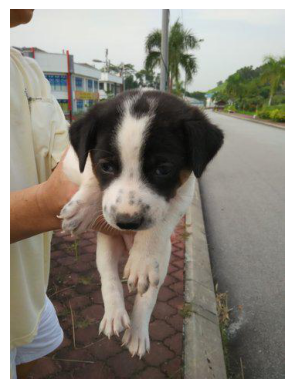

In [41]:
from PIL import Image
import matplotlib.pyplot as plt

img_name = os.listdir(image_folder)[0]
img_path = os.path.join(image_folder, img_name)

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

In [42]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [43]:
img_tensor = transform(img)
print(img_tensor.shape)

torch.Size([3, 224, 224])


In [44]:
import torch
import torchvision.models as models

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [45]:
img_tensor = img_tensor.unsqueeze(0)

with torch.no_grad():
    features = model(img_tensor)

print(features.shape)

torch.Size([1, 512, 1, 1])


In [46]:
features = features.view(-1).numpy()
print(features.shape)

(512,)


In [48]:
import os
from PIL import Image
import torch

image_folder = "../data/raw/train_images/"

image_features = {}

for pet_id in df["PetID"].head(100):
    try:
        img_name = f"{pet_id}-1.jpg"
        img_path = os.path.join(image_folder, img_name)

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert("RGB")

        img_tensor = transform(img)
        img_tensor = img_tensor.unsqueeze(0)

        with torch.no_grad():
            feature = model(img_tensor)

        feature = feature.view(-1).numpy()

        image_features[pet_id] = feature

    except Exception as e:
        print(f"Error with {pet_id}: {e}")

In [49]:
import pandas as pd

img_df = pd.DataFrame.from_dict(image_features, orient="index")
img_df.columns = [f"img_{i}" for i in range(512)]

img_df.reset_index(inplace=True)
img_df.rename(columns={"index": "PetID"}, inplace=True)

img_df.head()

,PetID,img_0,img_1,img_2,img_3,img_4,img_5,img_6,img_7,img_8,...,img_502,img_503,img_504,img_505,img_506,img_507,img_508,img_509,img_510,img_511
0,86e1089a3,0.903852,1.041304,1.355550,1.700732,0.064104,1.347213,0.318015,0.982026,0.618271,...,0.904255,0.570885,0.118197,0.451893,0.612294,0.583564,3.391499,2.450972,0.385905,0.753335
1,6296e909a,0.303067,0.334013,0.148037,4.458599,0.235277,1.242376,0.323908,1.872383,0.457328,...,0.813743,0.062888,0.050094,0.752480,1.215092,0.201903,0.624320,1.740309,1.008938,0.259278
2,3422e4906,0.910024,0.971462,0.595676,3.037544,1.009423,0.183450,0.157591,0.526364,0.749239,...,1.102538,0.405760,0.009102,0.371037,2.178843,0.654859,0.021383,3.224112,0.225140,0.041032
3,5842f1ff5,0.852909,0.358313,1.394704,1.052627,0.376062,0.305294,1.044556,4.007650,2.131758,...,1.500481,0.658891,0.092310,0.686471,1.986665,0.165115,1.206696,2.837876,1.823462,0.512186
4,850a43f90,2.501181,0.410667,0.001621,0.339244,0.212985,0.294125,0.195546,1.642623,0.867173,...,1.070047,0.840392,0.054161,1.583807,2.683774,0.003404,0.219252,1.823267,1.392111,0.814600


In [52]:
import os

os.makedirs("../data/processed", exist_ok=True)
img_df.to_csv("../data/processed/img_meta.csv", index=False)